In [108]:
import requests
from IPython.core.display import HTML
# HTML(f"""
# <style>
# @import "https://cdn.jsdelivr.net/npm/bulma@0.9.4/css/bulma.min.css";
# </style>
# """)

# Polynomial models

**Overview**
In this exercise you will implement a method to estimate/learn the model parameters of single variate (single input) 2-nd and 3-rd order polynomials and use these models to predict labels for new datapoints. Next week you will extend this method to $n$-th order, single variate polynomials. 


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#inclass">Task 1: In-class exercise</a>
            </li>
            <li>
            <a href="#loading7">Task 2: Data preparation (data wrangling)</a>
            </li>
            <li>
            <a href="#loading8">Task 3: Constructing the design matrix</a>
            </li>
            <li>
            <a href="#loading9">Task 4: Inverting the design matrix</a>
            </li>
            <li>
            <a href="#loading10">Task 5: Plotting</a>
            </li>
            <li>
            <a href="#loading10130">Task 6: Making predictions</a>
            </li>
            <li>
            <a href="#loading12">Task 7: Load data</a>
            </li>
            <li>
            <a href="#loading11">Task 8: Third order polynomials</a>
            </li>
            <li>
            <a href="#loading13">Task 9: Plotting</a>
            </li>
            <li>
            <a href="#loading145">Task 10: Observe</a>
            </li>
            <li>
            <a href="#loading100">Task 11: Making predictions</a>
            </li>
            <li>
            <a href="#loading1030">Task 12: Observe</a>
            </li>
        </ul>
    </div>
</article>

## 1st-order Polynimial model

---
**Task 1 (easy): In-class exercise👩‍💻**
1. Finish all of the tasks from the W3 in-class exercise
.

**Note:** If you attented the lecture and in-class exercise you are all set.


---
## 2nd-order Polynomial model
A 2nd-order polynomial model, also known as a quadratic model, can be expressed as:

$$ y = w_0 + w_1 x + w_2 x^2 $$
This non-linear model assumes that the relationship between the input $x$ and the label $y$ is quadratic. This way a "curved" relationship between inputs and outputs can be modelled which can capture patterns that a simple linear model might miss. 
By _fitting_ this model, the aim is to learn the parameters $w_0$, $w_1$, and $w_2$ that minimize the difference (the error) between the predicted values and the output (labels), providing a more flexible fit compared to a linear model.
**Note:** In this exercise a minimum number of points to fit the model is used, therefore the error between predicted values and actual data will always be 0.


---
**Task 2 (easy): Load data👩‍💻**
1. Run the cell below to load libraries and construct the datasets.


---

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import util_week3 #import exercise specific functionality

quadratic_dataset_1 = np.array([[1, 2], 
                                [2, 3], 
                                [3, 6]])

quadratic_dataset_2 = np.array([[9, 3], 
                                [7, 5], 
                                [1, 9]])

quadratic_dataset_3 = np.array([[8, 4], 
                                [10, 5], 
                                [3, 1]])

Throughout the next tasks, the aim is to construct the design matrix using the known variables, followed by learning the model parameters (solving) using the inverse of the design matrix. The subsequent tasks involve using the learnt model parameters to predict new unseen inputs and plotting the results.

---
**Task 3 (easy): Data preparation (data wrangling)👩‍💻**
1. For each dataset identify which values correspond to inputs and which are the labels.
2. Complete the `separate_inputs_labels`
 function below. The function takes a dataset as input and returns the inputs as the `X_quadratic`
 matrix and the labels as the `y_quadratic`
 vector.


---

In [110]:
def separate_inputs_labels(dataset):
    """
    This function takes a dataset as input and returns the inputs and labels.
    
    Parameters:
    dataset (numpy array): The dataset to be separated.
    
    Returns:
    X_quadratic (3x1 numpy array): The input matrix.
    y_quadratic (1x3 numpy array): The labels vector.
    """

    X_quadratic = dataset[:, :-1] # All rows (:), all columns except the last (:-1)
    y_quadratic = dataset[:, -1] # All rows (:), only the last column (-1)
    return X_quadratic, y_quadratic

# Applying the function to each quadratic dataset
X1_quadratic, y1_quadratic = separate_inputs_labels(quadratic_dataset_1)
X2_quadratic, y2_quadratic = separate_inputs_labels(quadratic_dataset_2)
X3_quadratic, y3_quadratic = separate_inputs_labels(quadratic_dataset_3)

print("X1_quadratic: \n", X1_quadratic)
print("y1_quadratic: \n", y1_quadratic)

X1_quadratic: 
 [[1]
 [2]
 [3]]
y1_quadratic: 
 [2 3 6]



---
**Task 4 (easy): Constructing the design matrix👩‍💻**
Reuse the code from the W3 in-class exercise
:
1. For each data set construct the design matrix for a 2nd order polynomial.
2. Print the results.


---

In [111]:
def quadratic_design_matrix(X):
    """
    This function takes an input matrix X and returns the design matrix by adding a column of ones and a column of squared terms.
    
    Parameters:
    X (numpy array): The input matrix.
    
    Returns:
    X_design (numpy array): The design matrix.
    """
    n, m = X.shape  # get dimensions of X
    ones_column = np.ones((n, 1))  # create a column of ones with n rows and 1 column
    X_design = np.column_stack((X**2, X, ones_column))  # stack the squared terms, original X, and ones column
    return X_design

# Creating design matrices for each dataset
X1_quadratic_design = quadratic_design_matrix(X1_quadratic)
X2_quadratic_design = quadratic_design_matrix(X2_quadratic)
X3_quadratic_design = quadratic_design_matrix(X3_quadratic)
print("Design Matrix for Dataset 1:\n", X1_quadratic_design)
print("Design Matrix for Dataset 2:\n", X2_quadratic_design)
print("Design Matrix for Dataset 3:\n", X3_quadratic_design)

Design Matrix for Dataset 1:
 [[1. 1. 1.]
 [4. 2. 1.]
 [9. 3. 1.]]
Design Matrix for Dataset 2:
 [[81.  9.  1.]
 [49.  7.  1.]
 [ 1.  1.  1.]]
Design Matrix for Dataset 3:
 [[ 64.   8.   1.]
 [100.  10.   1.]
 [  9.   3.   1.]]



---
**Task 5 (easy): Inverting the design matrix👩‍💻**
1. Compute the inverse of each design matrix.
2. Compute the model parameters (referenced as `weigths`
 in the cells below), then print the results.


---

In [ ]:
# Function to verify invertibility. This is just for debugging purposes, as we assume that the datasets are well-posed.
def verify_invertibility(X_design):
    """
    This function verifies the invertibility of the matrix (X_design^T * X_design).
    Since a matrix is invertible if its determinant is non-zero, we will check that.
    To avoid numerical instability, we round the determinant to the nearest integer before checking.

    Parameters:
    X_design (numpy array): The design matrix.

    Returns:
    bool: True if the matrix is invertible, False otherwise.
    """
    A = X_design.T @ X_design
    return np.linalg.det(A).round() != 0

# We can compute the weights using the formula w = (A^T * A)^-1 * A^T * b:
# Since our design matrix is square (because we have exactly as many data points as parameters), we could actually just use the formula: w = A^-1 * b (if A is invertible)
# But for consistency, we'll use the general formula.
def compute_weights(X_design, y):
    """
    This function computes the weights using the normal equation:
    w = (A^T * A)^-1 * A^T * b
    
    Parameters:
    X_design (numpy array): The design matrix.
    y (numpy array): The labels vector.
    
    Returns:
    weights (numpy array): The computed weights.
    """
    if not verify_invertibility(X_design):
        print("Matrix is not invertible.")
        return None
    weights = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    return weights

# Computing weights for each dataset
weights1_quadratic = compute_weights(X1_quadratic_design, y1_quadratic)
weights2_quadratic = compute_weights(X2_quadratic_design, y2_quadratic)
weights3_quadratic = compute_weights(X3_quadratic_design, y3_quadratic)

print("Model parameters for Model 1:", weights1_quadratic)
print("Model parameters for Model 2:", weights2_quadratic)
print("Model parameters for Model 3:", weights3_quadratic)

Model parameters for Model 1: [ 1. -2.  3.]
Model parameters for Model 2: [-0.04166667 -0.33333333  9.375     ]
Model parameters for Model 3: [-0.01428571  0.75714286 -1.14285714]



---
**Task 6 (easy): Plotting👩‍💻💡**
1. Use the `plot_quadratic_model`
 function from the `util_polynimial.py`
 file to plot the results. The input parameters are:    
 - `X`
(Nx1 numpy array): input
- `y`
(Nx1 numpyarray): labels
- `weights`
(Nx1 numpyarray): model weights 




---

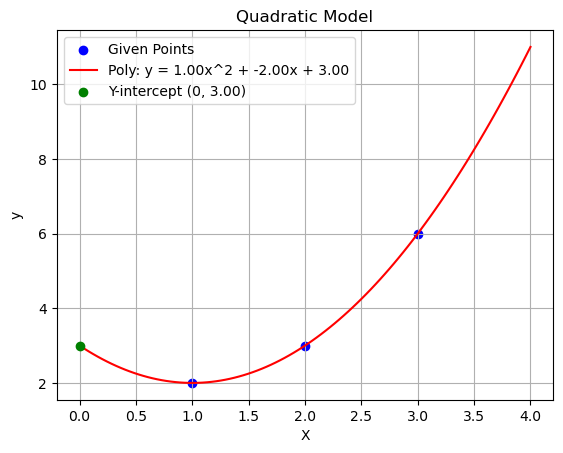

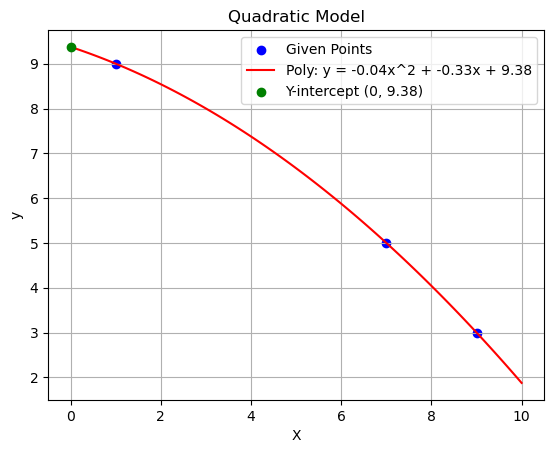

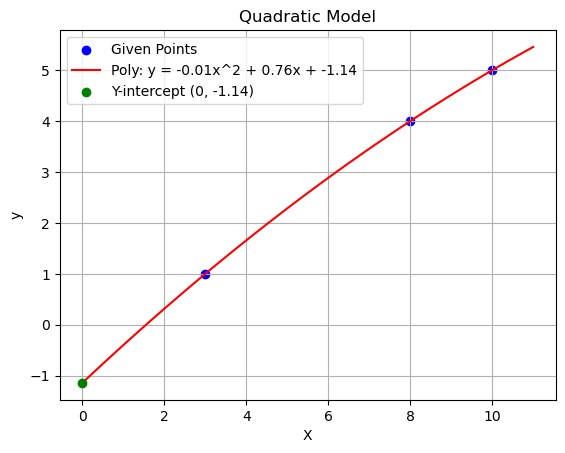

In [113]:
util_week3.plot_quadratic_model(X1_quadratic, y1_quadratic, weights1_quadratic)
util_week3.plot_quadratic_model(X2_quadratic, y2_quadratic, weights2_quadratic)
util_week3.plot_quadratic_model(X3_quadratic, y3_quadratic, weights3_quadratic)


---
**Task 7 (easy): Observe💡**
1. Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve. 
2. Compare the results of the polynomial model to the outcome of the linear model implemented in the in-class exercise.
3. What are the precited value for $x = 0.5, x = 2.5, x = 3.5$, how does it relate to the graph?


---

1. **Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve.**
The model parameters (weights) determine the specific characteristics of the fitted quadratic curve. The parameter $w_0$ represents the y-intercept, which is where the curve crosses the y-axis. The parameter $w_1$ influences the slope of the curve at the y-intercept, affecting how steeply the curve rises or falls as x increases. The parameter $w_2$ determines the curvature of the parabola; a positive $w_2$ results in a U-shaped curve (concave up), while a negative $w_2$ produces an inverted U-shape (concave down). Together, these parameters shape the overall position and orientation of the quadratic curve on the graph.

2. **Compare the results of the polynomial model to the outcome of the linear model implemented in the in-class exercise.**
Both the linear and the polynomial models are created using the least data points required to fit the model, hence both achieve a perfect fit with zero error.
While the linear model can only capture straight-line relationships, the polynomial model can accommodate curves.

3. **What are the predicted values for $x = 0.5, x = 2.5, x = 3.5$, how does it relate to the graph?**
The predicted values for the given x values can be calculated using the learned model parameters (weights) for each dataset.
In the graph, we can see that the predicted values correspond to specific points on the fitted quadratic curve. The value of the curve at these points represents the predicted output (y value) for each input (x value).
(see calculations and illustrations below)

Predictions for input: 
 [[0.5]
 [2.5]
 [3.5]] 
Model 1: 
 [[2.25]
 [4.25]
 [8.25]] 
Model 2: 
 [[9.19791667]
 [8.28125   ]
 [7.69791667]] 
Model 3: 
 [[-0.76785714]
 [ 0.66071429]
 [ 1.33214286]]


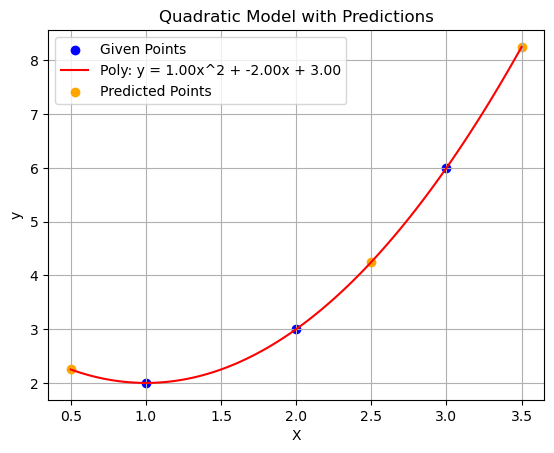

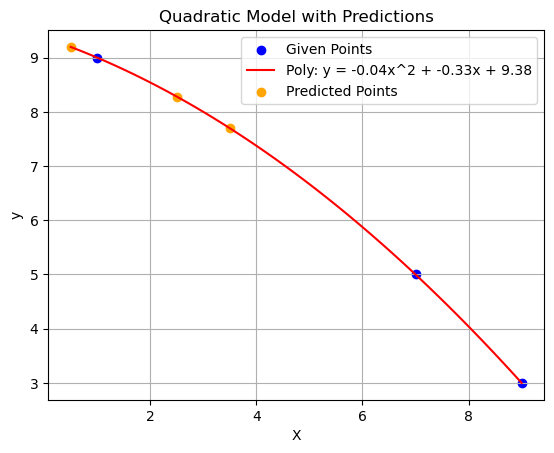

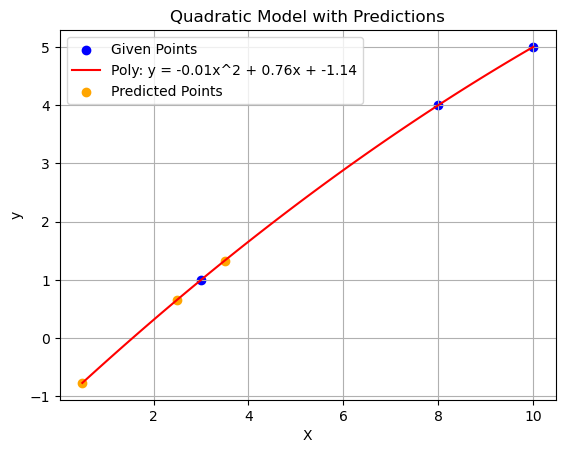

In [114]:
def predict_quadratic(input, weights):
    y_vals = weights[0] * input**2 + weights[1] * input + weights[2]
    return y_vals

input = np.array([[0.5],
                  [2.5],
                  [3.5]])
output1 = predict_quadratic(input, weights1_quadratic)
output2 = predict_quadratic(input, weights2_quadratic)
output3 = predict_quadratic(input, weights3_quadratic)
print("Predictions for input: \n", input, "\nModel 1: \n",output1, "\nModel 2: \n", output2, "\nModel 3: \n", output3)

util_week3.plot_quadratic_model_with_predictions(X1_quadratic, y1_quadratic, weights1_quadratic, input, output1)
util_week3.plot_quadratic_model_with_predictions(X2_quadratic, y2_quadratic, weights2_quadratic, input, output2)
util_week3.plot_quadratic_model_with_predictions(X3_quadratic, y3_quadratic, weights3_quadratic, input, output3)

Use the polynomial equation with the learned model parameters on the new inputs to make predictions.

---
**Task 8 (easy): Making predictions👩‍💻💡**
The cell below contains an array of new inputs. Follow these steps to predict a label for each the new input:
1. For each trained model, use the model parameters to predict a label for the new input. The model parameters for the different models should lead to different predictions. Store the predicted label as a separate variable. 
2. Plot the results using the function `plot_quadratic_model_with_predictions`
 from the `util_week3.py`
 file. The input parameters of the function are:    - `X`
(Nx1 numpy array): input
    - `y`
(Nx1 numpyarray): labels
    - `weights`
(Nx1 numpyarray): model weights 
    - `x`
(Mx1 numpy array): new inputs
    - `y'`
 (Mx1 numpy array): new input predictions


3. Compare the plots and the predicted labels obtained with the different models.
4. Extend the `new_inputs`
 array with the points `1.5`
 and `-1`
. Follow the same steps as above to obtain predicted labels for each input. 
5. Follow the steps above to predict 3 lavels for each model. A total of 9 predicted values must be submitted as part of the **mandatory** activity on [Grasple](https://app.grasple.com/#/courses/10532/ci/734077/diagnoses/12887)



---

Predictions for new input: [14.   1.5 -1. ] 
Model 1: 
 [171.     2.25   6.  ] 
Model 2: 
 [-3.45833333  8.78125     9.66666667] 
Model 3: 
 [ 6.65714286 -0.03928571 -1.91428571]


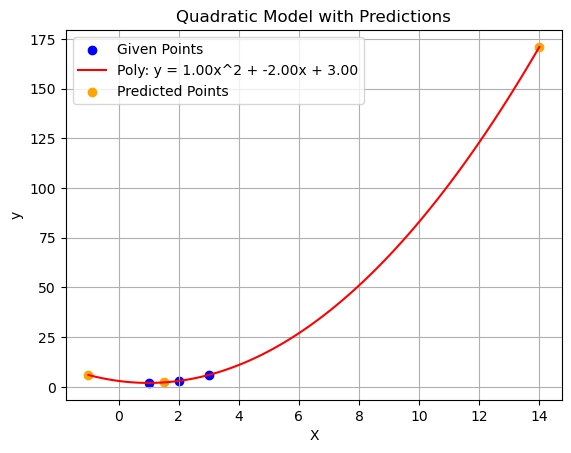

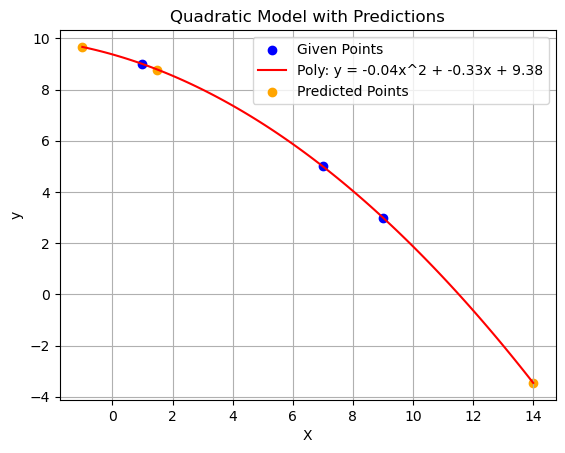

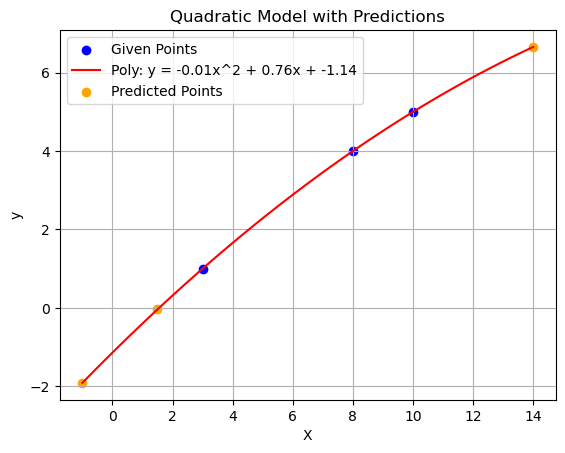

In [115]:
# New array of inputs for prediction, currently containing a single element
new_input = np.array([14, 1.5, -1])

def predict_quadratic(input, weights):
    y_vals = weights[0] * input**2 + weights[1] * input + weights[2]
    return y_vals

new_output1 = predict_quadratic(new_input, weights1_quadratic)
new_output2 = predict_quadratic(new_input, weights2_quadratic)
new_output3 = predict_quadratic(new_input, weights3_quadratic)
print("Predictions for new input:", new_input, "\nModel 1: \n", new_output1, "\nModel 2: \n", new_output2, "\nModel 3: \n", new_output3)

util_week3.plot_quadratic_model_with_predictions(X1_quadratic, y1_quadratic, weights1_quadratic, new_input, new_output1)
util_week3.plot_quadratic_model_with_predictions(X2_quadratic, y2_quadratic, weights2_quadratic, new_input, new_output2)
util_week3.plot_quadratic_model_with_predictions(X3_quadratic, y3_quadratic, weights3_quadratic, new_input, new_output3)

## 3rd-order Polynomial models
This exercise is about learning third order polynomials.
A 3rd-order polynomial model is given by:

$$ y = w_0 + w_1 x + w_2 x^2 + w_3 x^3 $$
A 3rd-order polynomial allow for more flexibility than the previous models by adding the cubic term $x^3$
In the next tasks you will follow similar steps as with 1. and 2. order polynomial. This includes:
1. Preparing the dataset.
2. Constructing the design matrix.
3. Calculating the model weights.
4. Plotting the results.
5. Using the model to make predictions for new inputs.


---
**Task 9 (easy): Load data👩‍💻**
1. Run the cell below to construct a new dataset.


---

In [116]:
cubic_dataset = np.array([[7, 6], [5, 24], [8, 60], [1, 120]])


---
**Task 10 (easy): Third order polynomials👩‍💻**
1. For the cubic dataset identify which values correspond to inputs and which are the ground truth labels.
2. Create a $4 \times 1$ matrix called `X_cubic`
 that contain the inputs, and a vector called `y_cubic`
 containing the corresponding ground truth labels.
3. Create the design matrix for the cubic model.
4. Calculate the inverse of the design matrix.
5. Follow the same procedure as previous to compute the model parameters.


---

In [ ]:
def separate_inputs_labels(dataset):
    """
    This function takes a dataset as input and returns the inputs and labels.
    
    Parameters:
    dataset (numpy array): The dataset to be separated.
    
    Returns:
    X_cubic (4x1 numpy array): The input matrix.
    y_cubic (1x4 numpy array): The labels vector.
    """

    X_cubic = dataset[:, :-1] # All rows (:), all columns except the last (:-1)
    y_cubic = dataset[:, -1] # All rows (:), only the last column (-1)
    return X_cubic, y_cubic

def cubic_design_matrix(X):
    """
    This function takes an input matrix X and returns the design matrix by adding a column of ones, a column of squared terms, and a column of cubic terms.
    
    Parameters:
    X (numpy array): The input matrix.
    
    Returns:
    X_design (numpy array): The design matrix.
    """
    n, m = X.shape  # get dimensions of X
    ones_column = np.ones((n, 1))  # create a column of ones with n rows and 1 column
    X_design = np.column_stack((X**3, X**2, X, ones_column))  # stack the cubic terms, squared terms, original X, and ones column
    return X_design

def verify_invertibility(X_design):
    """
    This function verifies the invertibility of the matrix (X_design^T * X_design).
    Since a matrix is invertible if its determinant is non-zero, we will check that.
    To avoid numerical instability, we round the determinant to the nearest integer before checking.

    Parameters:
    X_design (numpy array): The design matrix.

    Returns:
    bool: True if the matrix is invertible, False otherwise.
    """
    A = X_design.T @ X_design
    return np.linalg.det(A).round() != 0

# We can compute the weights using the formula w = (A^T * A)^-1 * A^T * b:
# Since our design matrix is square (because we have exactly as many data points as parameters), we could actually just use the formula: w = A^-1 * b (if A is invertible)
# But for consistency, we'll use the general formula.
def compute_weights(X_design, y):
    """
    This function computes the weights using the normal equation:
    w = (A^T * A)^-1 * A^T * b
    
    Parameters:
    X_design (numpy array): The design matrix.
    y (numpy array): The labels vector.
    
    Returns:
    weights (numpy array): The computed weights.
    """
    if not verify_invertibility(X_design):
        print("Matrix is not invertible.")
        return None
    weights = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
    return weights


# Applying the functions to the cubic dataset
print("Cubic Dataset:\n", cubic_dataset)
print("TASK 10.1 and 10.2: Identify and separate inputs and labels")
X_cubic, y_cubic = separate_inputs_labels(cubic_dataset)
print("X_cubic: \n", X_cubic)
print("y_cubic: \n", y_cubic)

print("TASK 10.3: Create the design matrix")
X_cubic_design = cubic_design_matrix(X_cubic)
print("X_cubic_design: \n", X_cubic_design)

print("TASK 10.4: Calculate the inverse of the design matrix")
inv_cubic_design = np.linalg.inv(X_cubic_design)
print("Inverse of Design Matrix for Cubic Dataset:\n", inv_cubic_design)

print("TASK 10.5: Compute the model parameters (weights)")
weights_cubic = compute_weights(X_cubic_design, y_cubic)
print("Weights for Cubic Dataset:", weights_cubic)



Cubic Dataset:
 [[  7   6]
 [  5  24]
 [  8  60]
 [  1 120]]
TASK 10.1 and 10.2: Identify and separate inputs and labels
X_cubic: 
 [[7]
 [5]
 [8]
 [1]]
y_cubic: 
 [  6  24  60 120]
TASK 10.3: Create the design matrix
X_cubic_design: 
 [[343.  49.   7.   1.]
 [125.  25.   5.   1.]
 [512.  64.   8.   1.]
 [  1.   1.   1.   1.]]
TASK 10.4: Calculate the inverse of the design matrix
Inverse of Design Matrix for Cubic Dataset:
 [[-0.08333333  0.04166667  0.04761905 -0.00595238]
 [ 1.16666667 -0.66666667 -0.61904762  0.11904762]
 [-4.41666667  2.95833333  2.23809524 -0.7797619 ]
 [ 3.33333333 -2.33333333 -1.66666667  1.66666667]]
TASK 10.5: Compute the model parameters (weights)
Weights for Cubic Dataset: [  2.64285714 -31.85714286  85.21428571  64.        ]



---
**Task 11 (easy): Plotting👩‍💻💡**
1. Use the `plot_cubic_model`
 function to plot the results. The input parameters of the function are:    - `X`
(Nx1 numpy array): input
    - `y`
(Nx1 numpyarray): labels
    - `weights`
(Nx1 numpyarray): model weights 


2. Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve.


---

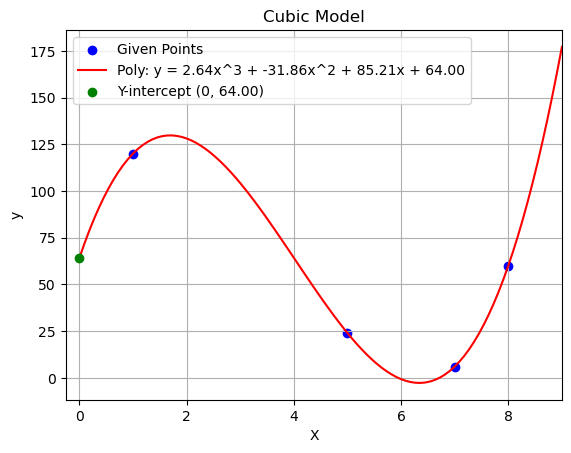

In [118]:
#Plot the data and fitted cubic model for the dataset
util_week3.plot_cubic_model(X_cubic, y_cubic, weights_cubic)

**TASK 11.2: Visually inspect the plots and discuss how the model parameters influence the shape and position of the fitted curve.**

Like with the quadratic model, the model parameters (weights) of the cubic polynomial determine the specific characteristics of the fitted curve. The parameter $w_0$ represents the y-intercept, which is where the curve crosses the y-axis. The parameter $w_1$ influences the slope of the curve at the y-intercept, affecting how steeply the curve rises or falls as x increases. The parameter $w_2$ affects the curvature of the parabola, while $w_3$ introduces additional flexibility to the curve, allowing it to have inflection points where it changes concavity. Together, these parameters shape the overall position and orientation of the cubic curve on the graph.

Compared to the quadratic model, we see that the cubic model's parameters $w_0$, $w_1$, and $w_2$ provide the same influence on the curve as in the quadratic model, while $w_3$ adds an additional layer of complexity, allowing the curve to bend and twist in ways that a quadratic curve cannot.

Like with the other models, the cubic model achieves a perfect fit with zero error due to the minimum number of data points used to fit the model (in this case, four data points).


---
**Task 12 (easy): Observe💡**
1. Compare the results of the 3rd order polynomial to the 1st and 2nd order models. Based on the plots, which model shows the best fit?
2. What happens when trying to fit the model using dataset 1, 2 and 3. What goes wrong?


---

**TASK 12.1: Compare the results of the 3rd order polynomial to the 1st and 2nd order models. Based on the plots, which model shows the best fit?**

All of the models (1st, 2nd, and 3rd order polynomials) achieve a perfect fit with zero error due to the minimum number of data points used to fit each model.
If we had more datapoints, we would likely see that the 3rd order polynomial could fit more complex patterns in the data compared to the 1st and 2nd order polynomials. However, if the data is inherently linear or quadratic, the 1st or 2nd order models might still provide a better fit without overfitting, and thereby showing better generalization to unseen data.

**TASK 12.1: What happens when trying to fit the model using dataset 1, 2 and 3. What goes wrong?**

When trying to fit a 3rd order polynomial model using dataset 1, 2, and 3, we encounter issues because these datasets do not contain enough data points to uniquely determine the four parameters of the cubic model. Specifically, a 3rd order polynomial requires at least four data points to fit the model without ambiguity.
As we see below, we encounter a problem when trying to compute the inverse of the design matrix transposed multiplied with the matrix itself (X_design^T * X_design) for these datasets, which indicates that the matrix is singular or not invertible.
This happens because there are not enough data points to provide a unique solution for the model parameters, leading to an underdetermined system.

In [119]:
# Trying to fit the cubic model using the datasets from the previous exercise with only 3 data points each:
X1, y1 = separate_inputs_labels(quadratic_dataset_1)
X2, y2 = separate_inputs_labels(quadratic_dataset_2)
X3, y3 = separate_inputs_labels(quadratic_dataset_3)
X1_design = cubic_design_matrix(X1)
X2_design = cubic_design_matrix(X2)
X3_design = cubic_design_matrix(X3)
weights1 = compute_weights(X1_design, y1)
weights2 = compute_weights(X2_design, y2)
weights3 = compute_weights(X3_design, y3)

Matrix is not invertible.
Matrix is not invertible.
Matrix is not invertible.



---
**Task 13 (easy): Making predictions👩‍💻💡**
In this task, the learned 3rd order polynomial model is used to predict labels for the `new_inputs`
 array defined below.
1. Use the obtained cubic model parameters to predict labels for the new inputs. 
2. Plot the results using the `plot_cubic_model_with_predictions`
 function in the `util_polynomial.py`
 file. The input parameters of the function are:    - `X`
(Nx1 numpy array): input
    - `y`
(Nx1 numpyarray): labels
    - `weights`
(Nx1 numpyarray): model weights 
    - `x`
(Mx1 numpy array): new inputs
    - `y'`
 (Mx1 numpy array): new input predictions




---

Labels for new inputs [14.   1.5 -1. ] :
 [2265.          129.0625      -55.71428571]


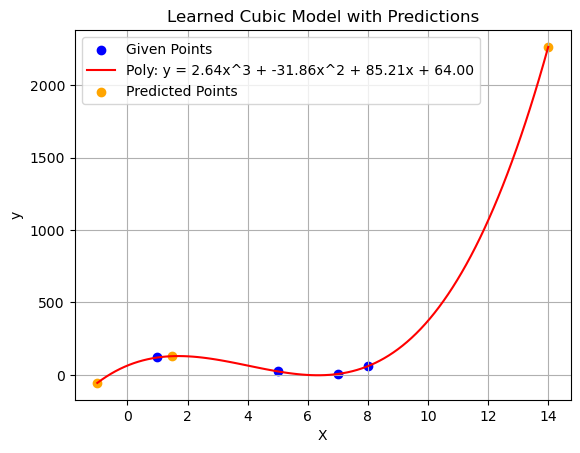

In [125]:
new_inputs = np.array([14, 1.5, -1])
def make_cubic_predictions(input, weights):
    y_vals = weights[0] * input**3 + weights[1] * input**2 + weights[2] * input + weights[3]
    return y_vals

new_outputs = make_cubic_predictions(new_inputs, weights_cubic)
print("Labels for new inputs", new_inputs, ":\n", new_outputs)

util_week3.plot_cubic_model_with_predictions(X_cubic, y_cubic, weights_cubic, new_inputs, new_outputs)


---
**Task 14 (easy): Observe💡**
1. What are the precited value for $x = 3$, $x = 6$, $x = 12$, how does it relate to the graph?
2. Compare the predictions of the cubic model with the predicitons of the quadratic models.
3. Which model is prefered in terms of representing the relationship between inputs and outputs and why?
4. What is the difference between the design matrix and the data matrix?
5. What is the difference between the design matrices of different order polynomials? And how does that relate to the datamatrix?


---

**Task 14.1: What are the predicted value for $x = 3$, $x = 6$, $x = 12$, how does it relate to the graph?**

The predicted values for the given x values can be calculated using the learned model parameters (weights) for the cubic model, but we can also read them in the graph above where the points on the fitted cubic curve correspond to the predicted outputs for these inputs.
The predicted values read from the graph are:
x = 3: y ≈ 100
x = 6: y ≈ 0.0
x = 12: y ≈ 1100
(see mathematical calculations of the predicted values below)

**Task 14.2: Compare the predictions of the cubic model with the predictions of the quadratic models.**

The predicted values from both the cubic and the quadratic models is represented as points on the curves in the respective graphs above. 
The calculated predicted values can be seen below, but are approximately:

| x   | Quadratic Prediction Model 1/2/3 | Cubic Prediction |
|-----|----------------------------------|------------------|
| 3   |   6   / 8   / 1                  |   104            |
| 6   |   27  / 6  / 3                   |   0              |
| 12  |   123 / -1 / 6                   |   1066           |

Another quadratic model might have given the same predictions as the cubic model for these specific inputs, but with the given quadratic models, the predictions differ significantly, especially for larger x values like 12. 
We do not know how good the predictions are, since we do not have the ground truth labels for these inputs, but we see that it is very important to choose the right model for the data.

**Task 14.3: Which model is preferred in terms of representing the relationship between inputs and outputs and why?**
The choice between a quadratic and cubic model depends on the underlying relationship between the inputs and outputs in the data.
If the relationship is inherently quadratic, a quadratic model is preferred due to its simplicity and lower risk of overfitting. However, if the data exhibits more complex patterns that a quadratic model cannot capture, a cubic model may be more appropriate.
Generally, the model that best balances fit and generalization to unseen data is preferred.
And a rule of thumb is to choose the simplest model that adequately captures the data patterns.

**Task 14.4: What is the difference between the design matrix and the data matrix?**
The data matrix contains the raw input data, while the design matrix is a transformed version of the data matrix that includes additional features or basis functions (like polynomial terms) to facilitate model fitting. For example, in polynomial regression, the design matrix includes columns for each power of the input variable.

**Task 14.5: What is the difference between the design matrices of different order polynomials? And how does that relate to the data matrix?**
The design matrices of different order polynomials differ in the number of columns they contain, which correspond to the polynomial terms included in the model. For a 1st-order polynomial (linear model), the design matrix has two columns: one for the intercept (x^0=1) and one for the linear term (x^1=x). For a 2nd-order polynomial, it has three columns (intercept, linear term, and quadratic term (x^2)). For a 3rd-order polynomial, it has four columns (intercept, linear term, quadratic term, and cubic term (x^3)).

The data matrix remains the same across different polynomial orders, as it contains the original input data. The design matrix is derived from the data matrix by applying the polynomial transformation, which adds complexity to the model and allows it to capture more intricate relationships in the data.
The only restriction is that the number of data points (rows in the data matrix) must be at least equal to the number of parameters (columns in the design matrix) to ensure a unique solution for the model parameters.


In [154]:
new_input = np.array([3, 6, 12])
new_cubic_output = make_cubic_predictions(new_input, weights_cubic)
formatted_outputs = [f"{val:.2f}" for val in new_cubic_output]
print("Predictions for new input:", new_input, "\n using cubic model: \n ≈", formatted_outputs)

new_quadratic_output1 = predict_quadratic(new_input, weights1_quadratic)
formatted_outputs1 = [f"{val:.2f}" for val in new_quadratic_output1]
print("\n using quadratic model 1: \n ≈", formatted_outputs1)
new_quadratic_output2 = predict_quadratic(new_input, weights2_quadratic)
formatted_outputs2 = [f"{val:.2f}" for val in new_quadratic_output2]
print("\n using quadratic model 2: \n ≈", formatted_outputs2)
new_quadratic_output3 = predict_quadratic(new_input, weights3_quadratic)
formatted_outputs3 = [f"{val:.2f}" for val in new_quadratic_output3]
print("\n using quadratic model 3: \n ≈", formatted_outputs3)


Predictions for new input: [ 3  6 12] 
 using cubic model: 
 ≈ ['104.29', '-0.71', '1066.00']

 using quadratic model 1: 
 ≈ ['6.00', '27.00', '123.00']

 using quadratic model 2: 
 ≈ ['8.00', '5.88', '-0.63']

 using quadratic model 3: 
 ≈ ['1.00', '2.89', '5.89']



---
**Task 15 (easy): Observe💡**
1. For which values of $x$ is $y = 0$? 
2. How many of these exists?


---

**TASK 15**
In the graph above, we can see that the cubic curve intersects the x-axis (where y=0) at three points (This is also the maximum number of roots a cubic polynomial can have). 
By visually inspecting the graph, we can estimate that these points are approximately at:
1. x ≈ -0,5
2. x ≈ 5,9
3. x ≈ 6,2
